In [ ]:
%% [markdown]
# Floorplan Semantic Segmentation Notebook

This notebook demonstrates an end-to-end semantic segmentation pipeline for floorplan room classification using DeepLabV3+ in PyTorch.

**Steps:**
1. Install dependencies
2. Define dataset and data loaders with augmentations
3. Build DeepLabV3+ model
4. Train and validate
5. Inference and post-processing9

---

UsageError: Cell magic `%%` not found.


In [ ]:
%%
1) Install / import libraries

In [ ]:
!pip install albumentations opencv-python tqdm

In [ ]:
import os
from glob import glob
import cv2
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet50
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from PIL import Image

In [ ]:
# # %% [markdown]
# ## 2) Dataset Definition

# We create a `FloorplanDataset` that loads images and grayscale mask maps (each pixel holds a class ID). Albumentations handles resizing, flips, and rotations.

# # %%

In [ ]:
# class FloorplanDataset(Dataset):
#     def __init__(self, img_dir, mask_dir, augment=False, img_size=(512,512)):
#         self.img_paths = sorted(glob(os.path.join(img_dir, '*.jpg')))
#         self.mask_paths = sorted(glob(os.path.join(mask_dir, '*.jpg')))
#         assert len(self.img_paths) == len(self.mask_paths), 'Mismatched image/mask counts'
#         self.augment = augment
#         self.img_size = img_size

#         aug_list = []
#         if augment:
#             aug_list += [
#                 A.HorizontalFlip(p=0.5),
#                 A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15, p=0.7)
#             ]
#         aug_list += [A.Resize(img_size[0], img_size[1])]
#         self.transform = A.Compose(aug_list + [ToTensorV2()])

#     def __len__(self):
#         return len(self.img_paths)

#     def __getitem__(self, idx):
#         img = cv2.cvtColor(cv2.imread(self.img_paths[idx]), cv2.COLOR_BGR2RGB)
#         mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

#         augmented = self.transform(image=img, mask=mask)
#         img_tensor = augmented['image'].float() / 255.0
#         mask_tensor = augmented['mask'].long()
#         return img_tensor, mask_tensor

In [ ]:
# # %% [markdown]
# ## 3) Instantiate DataLoaders

# Specify directories, class names, and parameters before running.

# # %%

# %% [markdown]
# # Floorplan Segmentation Dataset (no pre-split, `.jpg` only)
#
# We have:
#   - `/mnt/data/cnn_dataset/walls/*.jpg`    ← input images
#   - `/mnt/data/cnn_dataset/colors/*.jpg`   ← per-pixel masks
#
# We'll:
# 1. Enumerate all `.jpg` in `walls/`
# 2. Split 80/20
# 3. Build PyTorch `Dataset` / `DataLoader`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ROOT      = "/mnt/data/cnn_dataset"
# ROOT = 'content//drive//MyDrive//cnn_dataset'
ROOT = '/content/drive/MyDrive/cnn_dataset'
IMG_DIR   = os.path.join(ROOT, "walls")
MASK_DIR  = os.path.join(ROOT, "colors")
print(MASK_DIR)

all_fnames = sorted([
    os.path.basename(p)
    for p in glob(os.path.join(IMG_DIR, "*.png"))
])

train_fns, val_fns = train_test_split(all_fnames, test_size=0.2, random_state=42)
print(f"→ {len(train_fns)} train / {len(val_fns)} val images")

/content/drive/MyDrive/cnn_dataset/colors
→ 285 train / 72 val images


In [ ]:
# %% [markdown]
# ## Custom Dataset
# Loads `walls/<fname>.jpg` and `colors/<fname>.jpg`, returns
# `(image_tensor, mask_tensor)` where mask is `LongTensor` of shape H×W.

In [ ]:
color_map = {
    (0, 0, 0): 0,         # background
    (255, 154, 0): 1,       # bedroom/orange
    (50, 99, 155): 2,     # hallway/purple
    (0, 155, 255): 3,     # blue/bathroom
    (155, 255, 0): 4,   # yellow/living
    (100, 80, 71): 5        # brown/empty-room
}

def rgb_to_class(mask_rgb, color_map):
    """
    Converts an RGB mask to a class index mask using a color map.

    Args:
        mask_rgb (H, W, 3): RGB mask image
        color_map (dict): Dictionary {tuple(R,G,B): class_index}

    Returns:
        np.ndarray (H, W): mask with class indices
    """
    mask_class = np.zeros(mask_rgb.shape[:2], dtype=np.uint8)
    for color, class_idx in color_map.items():
        match = np.all(mask_rgb == color, axis=-1)
        mask_class[match] = class_idx
    return mask_class

  # Define manually or sample from your dataset
# class_names = ['background','bedroom','hallway','bathroom','living','empty-room]  # update as needed

In [ ]:
# def rgb_to_class(mask_rgb, color_map):
#     mask_class = np.zeros(mask_rgb.shape[:2], dtype=np.uint8)
#     for color, class_idx in color_map.items():
#         matches = np.all(mask_rgb == color, axis=-1)
#         mask_class[matches] = class_idx
#     return mask_class

In [ ]:
# # %%
# PALETTE = {
#     (255,   0,   0): 1,  # red → class 1
#     (  0,   0, 255): 2,  # blue → class 2
#     (  0, 255,   0): 3,  # green → class 3
#     # …
# }

class FloorplanDataset(Dataset):
    def __init__(self, img_dir, mask_dir, fn_list, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.fnames    = fn_list
        self.transform = transform

    def __len__(self):
        return len(self.fnames)

    # def __getitem__(self, idx):
    #     fname = self.fnames[idx]
    #     img_p  = os.path.join(self.img_dir,  fname)
    #     msk_p  = os.path.join(self.mask_dir, fname)

    #     img = Image.open(img_p).convert("RGB")
    #     msk = Image.open(msk_p)  # assume palette or grayscale where pixel IDs = class

    #     img = np.array(img)
    #     msk = np.array(msk, dtype=np.int64)

    #     if self.transform is not None:
    #         img, msk = self.transform(img, msk)

    #     return img, msk
    def __getitem__(self, idx):
        fname = self.fnames[idx]
        img = Image.open(os.path.join(self.img_dir,  fname)).convert("RGB")
        msk = Image.open(os.path.join(self.mask_dir, fname)).convert("RGB")

        img_np = np.array(img)
        msk_np = np.array(msk)  # H×W×3

        label = rgb_to_class(msk_np, color_map)

        # new array for class IDs
        # label = np.zeros((msk_np.shape[0], msk_np.shape[1]), dtype=np.int64)
        # for rgb, cid in PALETTE.items():
        #     matches = np.all(msk_np == rgb, axis=-1)
        #     label[matches] = cid

        if self.transform:
            img_t, msk_t = self.transform(img_np, label)
        else:
            # img_t, msk_t = img_np, label
            img_t, msk_t = T.ToTensor()(img_np), torch.from_numpy(label).long()

        return img_t, msk_t

In [ ]:
# # train_img_dir = 'data/train/images'
# train_img_dir = 'content/drive/MyDrive/cnn_dataset'
# train_mask_dir = 'data/train/masks'
# val_img_dir   = 'data/val/images'
# val_mask_dir  = 'data/val/masks'

# IMG_SIZE = (512, 512)
# BATCH_SIZE = 8
# NUM_WORKERS = 4

# train_ds = FloorplanDataset(train_img_dir, train_mask_dir, augment=True, img_size=IMG_SIZE)
# val_ds   = FloorplanDataset(val_img_dir,   val_mask_dir,   augment=False, img_size=IMG_SIZE)
# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
# val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
# %% [markdown]
# ## Transforms
# Convert to torch.Tensor, normalize, etc.

In [ ]:
# %%
def default_transform(image_np, mask_np):
    # image_np: H×W×3 uint8
    # mask_np:  H×W  int64
    img_t = T.ToTensor()(image_np)                  # → [0,1] float32 C×H×W
    # (optionally add Normalize here)

    msk_t = torch.from_numpy(mask_np).long()               # int64 H×W
    return img_t, msk_t

# IMAGENET_MEAN = [0.485, 0.456, 0.406]
# IMAGENET_STD  = [0.229, 0.224, 0.225]

# def default_transform(image_np, mask_np):
#     img_t = T.ToTensor()(image_np)                              # [0,1]
#     img_t = T.Normalize(IMAGENET_MEAN, IMAGENET_STD)(img_t)     # zero‑center + unit‑std
#     msk_t = torch.from_numpy(mask_np).long()                    # H×W
#     return img_t, msk_t

In [ ]:
# %% [markdown]
# ## Datasets & DataLoaders

In [ ]:
# %%
# create Dataset objects
train_ds = FloorplanDataset(IMG_DIR, MASK_DIR, train_fns, transform=default_transform)
val_ds   = FloorplanDataset(IMG_DIR, MASK_DIR, val_fns,   transform=default_transform)

# wrap in DataLoader
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2)

# quick sanity check
batch_imgs, batch_msks = next(iter(train_loader))
print("Batch image tensor:", batch_imgs.shape)  # → [B,3,H,W]
print("Batch mask tensor :", batch_msks.shape)   # → [B,H,W]

Batch image tensor: torch.Size([8, 3, 512, 512])
Batch mask tensor : torch.Size([8, 512, 512])


In [ ]:
# %% [markdown]
## 4) Model, Optimizer, Loss

Build DeepLabV3+ with a ResNet-50 backbone.

# %%

In [ ]:
import torch.nn as nn

class_names = ['background','bedroom','hallway','bathroom','living','empty-room']  # update as needed
NUM_CLASSES = len(class_names)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = deeplabv3_resnet50(pretrained_backbone=True, num_classes=NUM_CLASSES)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()

# class_weights = torch.tensor([1.0, 5.0, 1.0, 1.0, 1.0, 1.0], device=device)
# criterion = nn.CrossEntropyLoss(weight=class_weights)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights_backbone=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights_backbone=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 225MB/s]


In [ ]:
# %% [markdown]
## 5) Training & Validation Loops

Define helper functions and run epochs.

# %%

In [ ]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)['out']
        total_loss += criterion(outputs, masks).item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == masks).sum().item()
        total += masks.numel()
    return total_loss / len(loader.dataset), correct / total


def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)['out']
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)

In [ ]:
EPOCHS = 20
best_val_acc = 0.0
for epoch in range(1, EPOCHS+1):
    tr_loss = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print('  Saved new best model')

Epoch 1/20 | Train Loss: 0.7042 | Val Loss: 0.4340 | Val Acc: 0.9029
  Saved new best model
Epoch 2/20 | Train Loss: 0.2555 | Val Loss: 0.2156 | Val Acc: 0.9571
  Saved new best model
Epoch 3/20 | Train Loss: 0.1525 | Val Loss: 0.1383 | Val Acc: 0.9726
  Saved new best model
Epoch 4/20 | Train Loss: 0.1074 | Val Loss: 0.1015 | Val Acc: 0.9809
  Saved new best model
Epoch 5/20 | Train Loss: 0.0824 | Val Loss: 0.0836 | Val Acc: 0.9836
  Saved new best model
Epoch 6/20 | Train Loss: 0.0674 | Val Loss: 0.0676 | Val Acc: 0.9864
  Saved new best model
Epoch 7/20 | Train Loss: 0.0574 | Val Loss: 0.0596 | Val Acc: 0.9877
  Saved new best model
Epoch 8/20 | Train Loss: 0.0507 | Val Loss: 0.0557 | Val Acc: 0.9876
Epoch 9/20 | Train Loss: 0.0452 | Val Loss: 0.0528 | Val Acc: 0.9884
  Saved new best model
Epoch 10/20 | Train Loss: 0.0416 | Val Loss: 0.0467 | Val Acc: 0.9890
  Saved new best model
Epoch 11/20 | Train Loss: 0.0381 | Val Loss: 0.0463 | Val Acc: 0.9886
Epoch 12/20 | Train Loss: 0.0373

In [ ]:
# %% [markdown]
## 6) Inference & Post-processing

Run on a single test image and visualize.

# %%

In [ ]:
# def post_process(seg_map, min_area=500):
#     out = np.zeros_like(seg_map)
#     unique = np.unique(seg_map)
#     for cls in unique:
#         mask = (seg_map == cls).astype(np.uint8)
#         num_lbl, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
#         for lbl in range(1, num_lbl):
#             if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
#                 out[labels == lbl] = cls
#     return out

def post_process(seg_map, min_area=500):
    out = np.zeros_like(seg_map)
    unique_classes = np.unique(seg_map)

    for cls in unique_classes:
        mask = (seg_map == cls).astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

        for label in range(1, num_labels):  # Skip background
            area = stats[label, cv2.CC_STAT_AREA]
            if area >= min_area:
                out[labels == label] = cls

    return out

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

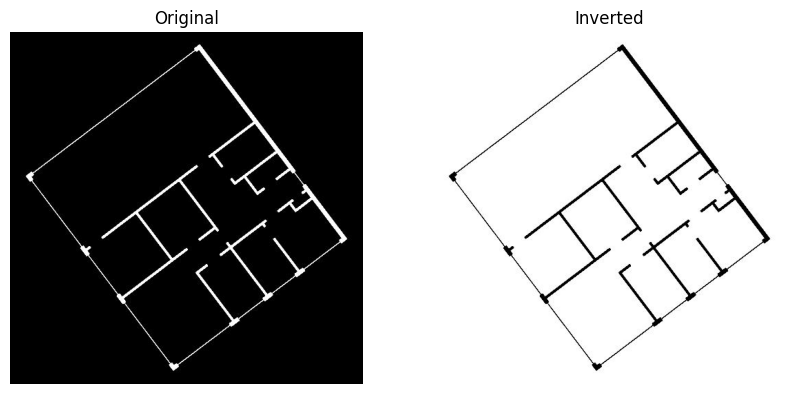

In [ ]:
import matplotlib.pyplot as plt

test_img_path = '/content/drive/MyDrive/cnn_dataset/test/image.jpg'  # update path
orig = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
H0, W0 = orig.shape[:2]
# ---- new inversion block ----
# convert to gray, invert, then back to 3‑channel RGB
orig_gray = cv2.cvtColor(orig, cv2.COLOR_RGB2GRAY)
inv_gray  = cv2.bitwise_not(orig_gray)
orig_inv  = cv2.cvtColor(inv_gray, cv2.COLOR_GRAY2RGB)
# ---- end inversion block ----

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.axis("off")
plt.imshow(orig)
plt.subplot(1,2,2)
plt.title("Inverted")
plt.axis("off")
plt.imshow(orig_inv)
plt.show()

In [ ]:
# %%
import argparse

color_maps = np.array([
    [0, 0, 0],
    [255, 154, 0],
    [50, 99, 155],
    [0, 155, 255],
    [155, 255, 0],
    [100, 80, 71]
], dtype=np.uint8)

test_img_path = '/content/drive/MyDrive/cnn_dataset/test/image.jpg'  # update path
orig = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
H0, W0 = orig.shape[:2]

# ---- new inversion block ----
# convert to gray, invert, then back to 3‑channel RGB
orig_gray = cv2.cvtColor(orig, cv2.COLOR_RGB2GRAY)
inv_gray  = cv2.bitwise_not(orig_gray)
orig_inv  = cv2.cvtColor(inv_gray, cv2.COLOR_GRAY2RGB)
# ---- end inversion block ----

IMG_SIZE = (512, 512)      # (width, height) or (W, H) as you used in training
inp = cv2.resize(orig, IMG_SIZE)
# inp_inv = cv2.resize(orig_inv, IMG_SIZE)
inp_tensor = T.ToTensor()(inp).unsqueeze(0).to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/cnn_dataset/best_model_final_4.pth', map_location=device))
model.eval()
with torch.no_grad():
    out = model(inp_tensor)['out'][0]
    prob = torch.softmax(out, dim=0).cpu().numpy()  # shape [C, H, W]
    print("max prob:", prob.max())
    conf = prob.max(axis=0)
    seg = prob.argmax(axis=0).astype(np.uint8)
    # seg[conf < 0.5] = 0  # if low confidence
    # seg = out.argmax(0).cpu().numpy().astype(np.uint8)
    seg = cv2.resize(seg, (W0, H0), interpolation=cv2.INTER_NEAREST)
    seg = post_process(seg)

# palette = np.array([np.random.randint(0,255,3) for _ in class_names])
overlay = color_maps[seg]
blend = ((0.8 * orig) + (2 * overlay)).astype(np.uint8)
# blend = ((1 * overlay)).astype(np.uint8)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.title('Original'); plt.axis('off'); plt.imshow(orig)
plt.subplot(1,2,2); plt.title('Segmentation Overlay'); plt.axis('off'); plt.imshow(blend)

# plt.imshow(conf, cmap='hot')
# plt.title("Prediction Confidence")
# plt.colorbar()
# plt.show()
# plt.imshow(seg, cmap='nipy_spectral')
# plt.title("Raw Predicted Class Map")
# plt.colorbar()
# plt.show()
# plt.imshow(prob[1], cmap='hot')
# plt.title("Probability for Orange Class (1)")
# plt.colorbar()
# plt.show()
# for i in range(prob.shape[0]):
#     plt.imshow(prob[i], cmap='hot')
#     plt.title(f'Probability for Class {i}')
#     plt.colorbar()
#     plt.show()

max prob: 0.99998677


NameError: name 'post_process' is not defined

In [ ]:
np.unique(seg, return_counts=True)

(array([0], dtype=uint8), array([262144]))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights_backbone=None`.
  warnings.warn(msg)


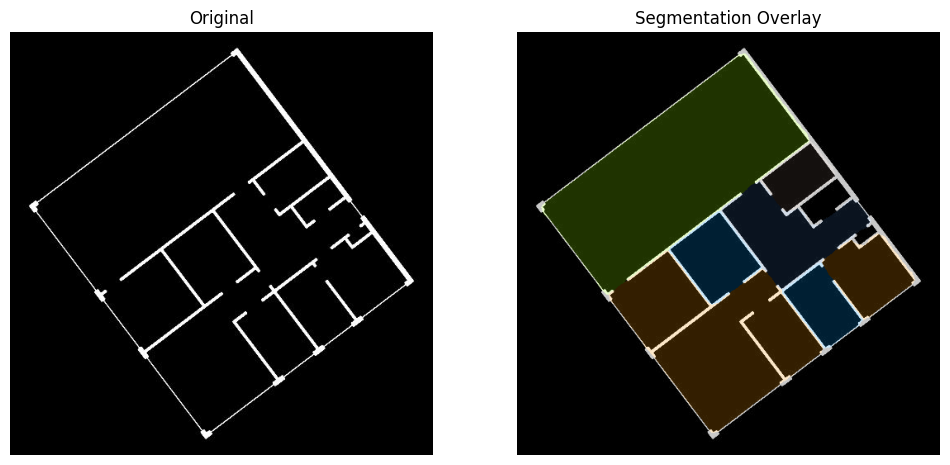

In [ ]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet50
from PIL import Image
import matplotlib.pyplot as plt

# Define the color map used during training
color_maps = np.array([
    [0, 0, 0],         # background
    [255, 154, 0],     # bedroom/orange
    [50, 99, 155],     # hallway/purple
    [0, 155, 255],     # blue/bathroom
    [155, 255, 0],     # yellow/living
    [100, 80, 71]      # brown/empty-room
], dtype=np.uint8)

# Function to perform post-processing (removing small connected components)
def post_process(seg_map, min_area=500):
    out = np.zeros_like(seg_map)
    unique_classes = np.unique(seg_map)

    for cls in unique_classes:
        mask = (seg_map == cls).astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

        for label in range(1, num_labels):  # Skip background
            area = stats[label, cv2.CC_STAT_AREA]
            if area >= min_area:
                out[labels == label] = cls

    return out

# Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the number of classes
NUM_CLASSES = len(color_maps)

# Load the trained model
model = deeplabv3_resnet50(pretrained_backbone=False, num_classes=NUM_CLASSES) # pretrained_backbone=False as we load a trained model state
model.load_state_dict(torch.load('/content/drive/MyDrive/cnn_dataset/best_model_final_4.pth', map_location=device))
model.to(device)
model.eval()

# Define the image size used during training
IMG_SIZE = (512, 512)

# Path to the test image
test_img_path = '/content/drive/MyDrive/cnn_dataset/test/image.jpg'  # update path

# Load and preprocess the test image
orig = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
H0, W0 = orig.shape[:2]

# Resize the image to the training size
inp = cv2.resize(orig, IMG_SIZE)

# Convert to tensor, add a batch dimension, and move to device
inp_tensor = T.ToTensor()(inp).unsqueeze(0).to(device)

# Perform inference
with torch.no_grad():
    out = model(inp_tensor)['out'][0]
    # Get the class with the highest probability for each pixel
    seg = out.argmax(0).cpu().numpy().astype(np.uint8)

# Resize the segmentation map back to the original image size
seg = cv2.resize(seg, (W0, H0), interpolation=cv2.INTER_NEAREST)

# Apply post-processing
seg = post_process(seg)

# Create an overlay of the segmentation mask on the original image
overlay = color_maps[seg]
blend = ((0.8 * orig) + (0.2 * overlay)).astype(np.uint8) # Adjusted blending factor for better visibility

# Display the original image and the segmentation overlay
plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.title('Original'); plt.axis('off'); plt.imshow(orig)
plt.subplot(1,2,2); plt.title('Segmentation Overlay'); plt.axis('off'); plt.imshow(blend)
plt.show()